# EDA

## Description

basically, if we train with imbalanced data, we will two major issues :
- **overfitting**: since we have 478 fraud cases of over 250 000 total transacion
- **Wrong Correlations**: since the 'V1 .. V28' features are already transformed with PCA for generally Privacy and protection of user credentials

in this notebook, our goals are Analysis and Processing the dataset through:
- removing duplications
- applying undersampling (choosing number of normal transactions equal to fraud)
- visualizing the distributions
- scaling the remaining features

In [9]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler, RobustScaler

In [48]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [49]:
dup = df.duplicated().sum()
print(dup)
if dup > 0:
    df = df.drop_duplicates()

1081


In [50]:
df.shape

(283726, 31)

In [51]:
print('No Frauds ==', df['Class'].value_counts()[0]/len(df) * 100, '% of the dataset')
print('Frauds =====', df['Class'].value_counts()[1]/len(df) * 100, '% of the dataset')

No Frauds == 99.83328986416473 % of the dataset
Frauds ===== 0.1667101358352777 % of the dataset


## EDA

In [52]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [53]:
# from sklearn.model_selection import train_test_split
# from sklearn.model_selection import StratifiedShuffleSplit
# from sklearn.model_selection import KFold, StratifiedKFold

# # separating the class from the rest of dataset

# X = df.drop('Class', axis=1) # withot class

# y = df['Class'] # class only

# sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False) # Creating StratifiedKFold Object for splitting

# for train_index, test_index in sss.split(X, y):
#     print("Train:", train_index, "Test:", test_index)
#     original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
#     original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

# # Turn into an array
# original_Xtrain = original_Xtrain.values
# original_Xtest = original_Xtest.values
# original_ytrain = original_ytrain.values
# original_ytest = original_ytest.values

# # See if both the train and test label distribution are similarly distributed
# train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
# test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)
# print('-' * 100)

# print('Label Distributions: \n')
# print(train_counts_label/ len(original_ytrain))
# print(test_counts_label/ len(original_ytest))

## UnderSampling

And now, we will select 437 cases of normal transactions, it will be randomly selected
- its purpose is only for visualization


In [69]:
# shuffling the data: shuffling after splitting is normal, since the train/test/labels variable are just lists that contains
# random shuffling
df = df.sample(frac=1)

fraud_num = df['Class'].value_counts()[1]

# amount of fraud classes .
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:fraud_num]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
US = normal_distributed_df.sample(frac=1, random_state=42)

print(US['Class'].value_counts()) # counting fraud and normal transactions separatly


Class
1    473
0    473
Name: count, dtype: int64


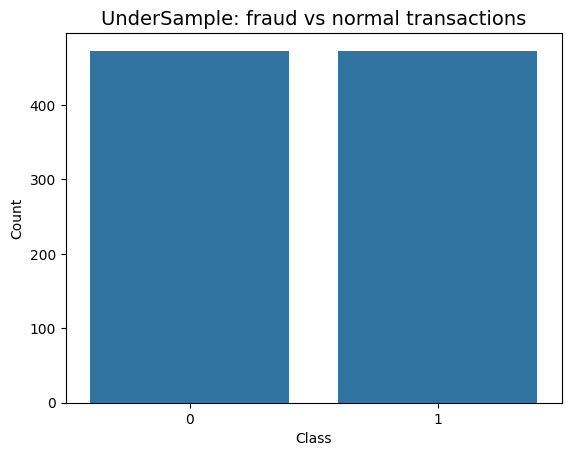

In [55]:
sns.countplot(x='Class', data=US)  # Note: Class 0 is normal transaction, 1 is fraud

plt.title("UnderSample: fraud vs normal transactions", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

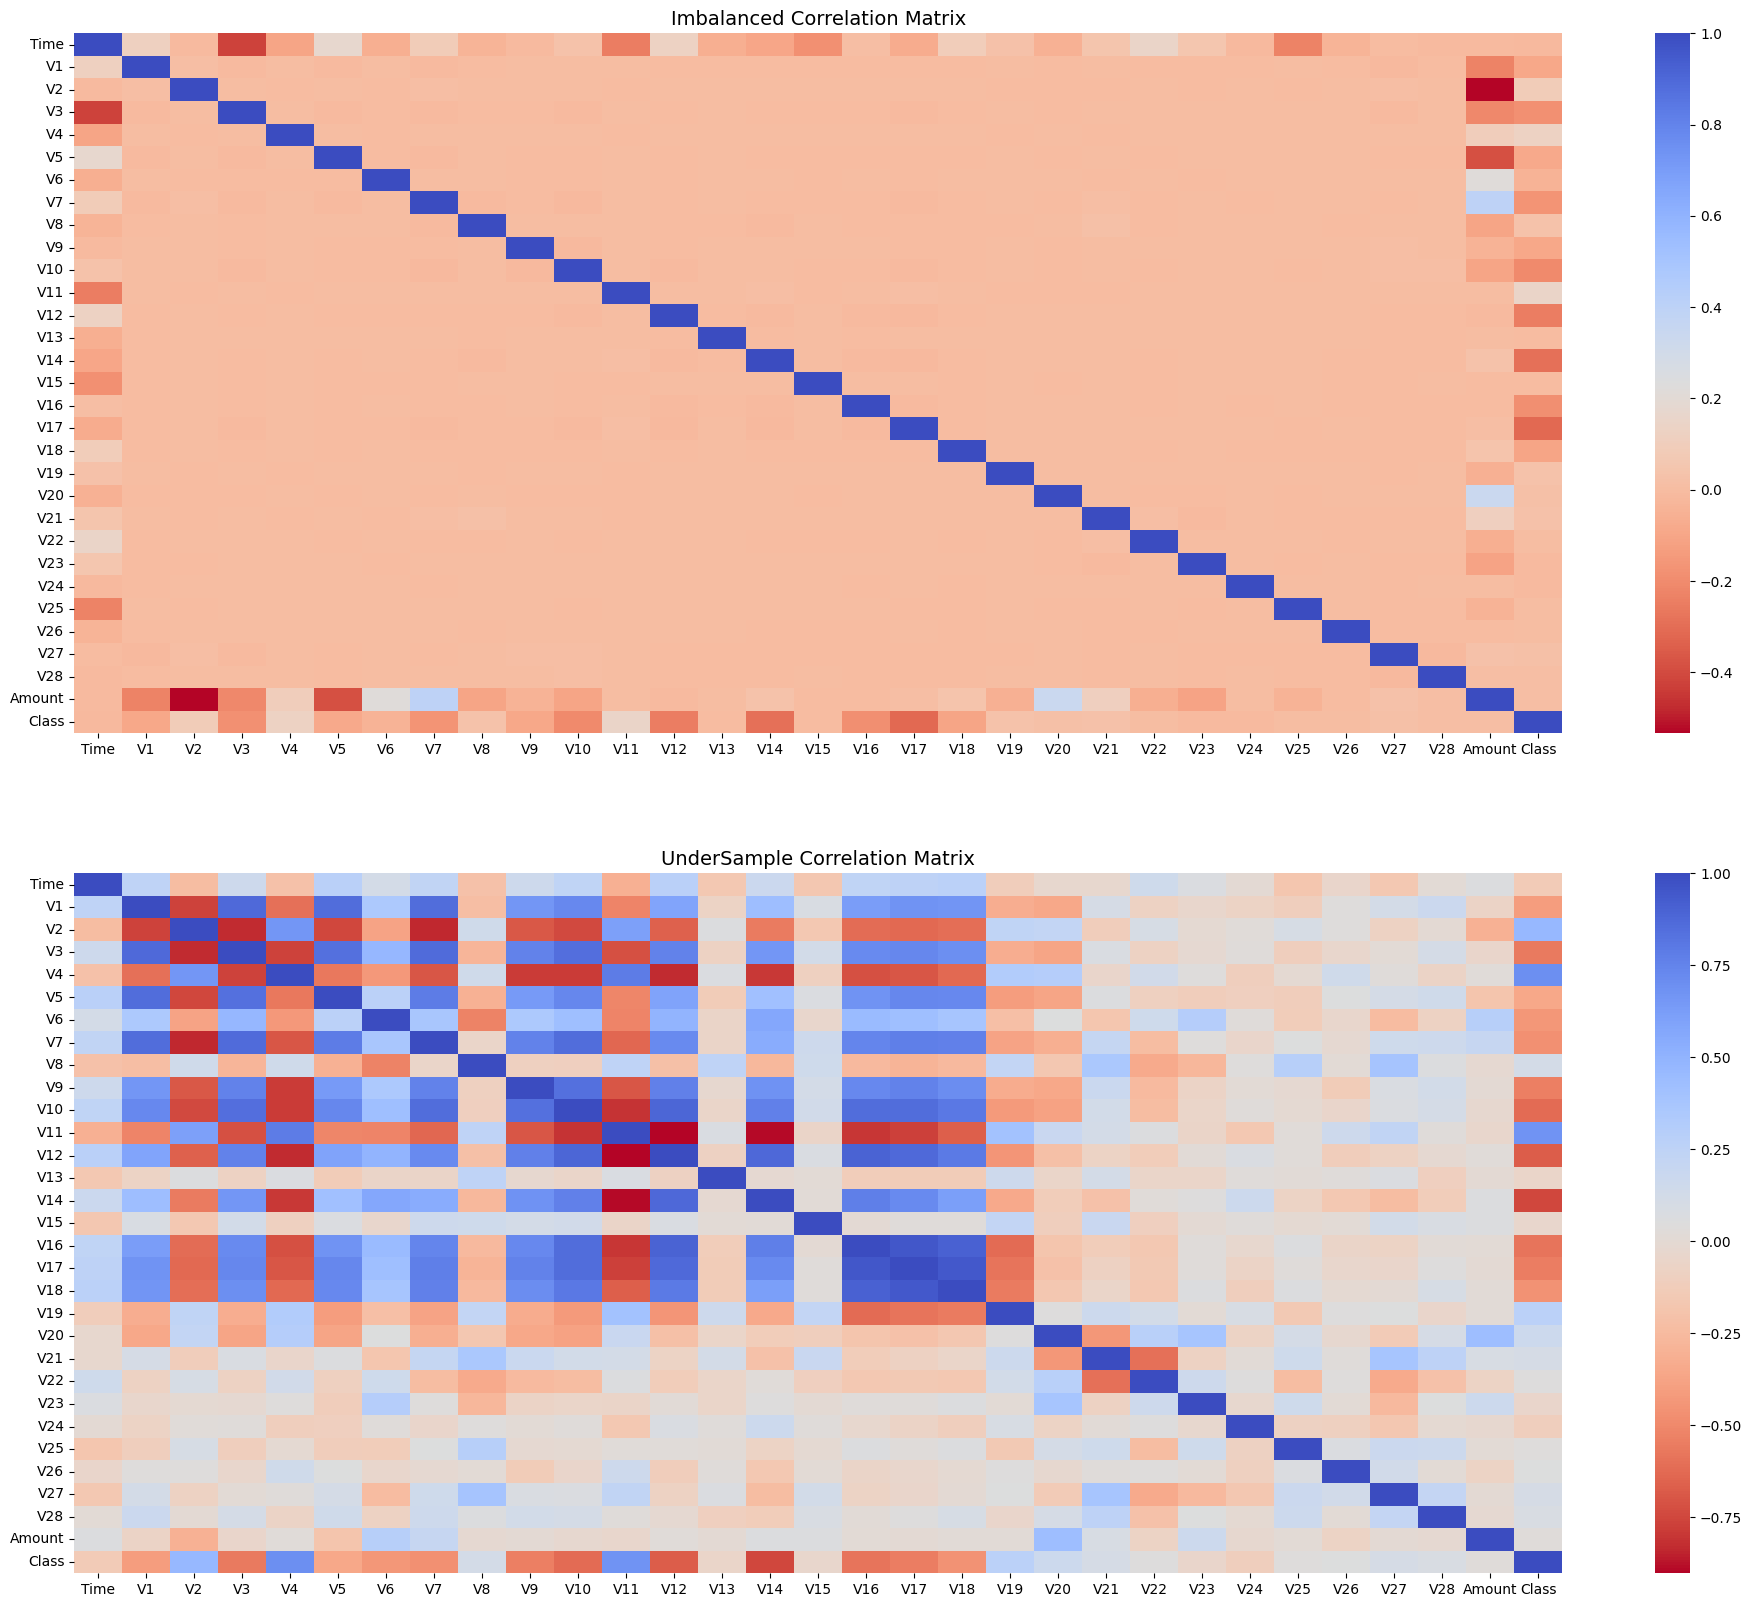

In [56]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# Entire DataFrame
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix", fontsize=14)


sub_sample_corr = US.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title('UnderSample Correlation Matrix', fontsize=14)
plt.show()

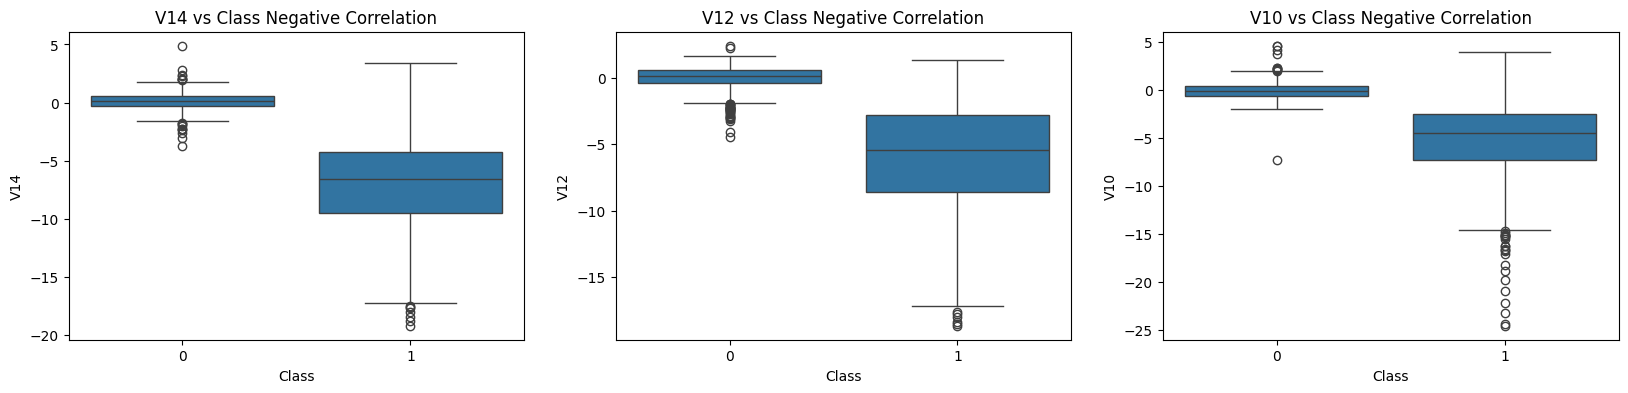

In [57]:
f, axes = plt.subplots(ncols=3, figsize=(20,4))

# Negative Correlations with our Class (The lower our feature value the more likely it will be a fraud transaction)

sns.boxplot(x="Class", y="V14", data=US, ax=axes[0])
axes[0].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V12", data=US, ax=axes[1])
axes[1].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V10", data=US, ax=axes[2])
axes[2].set_title('V10 vs Class Negative Correlation')

plt.show()

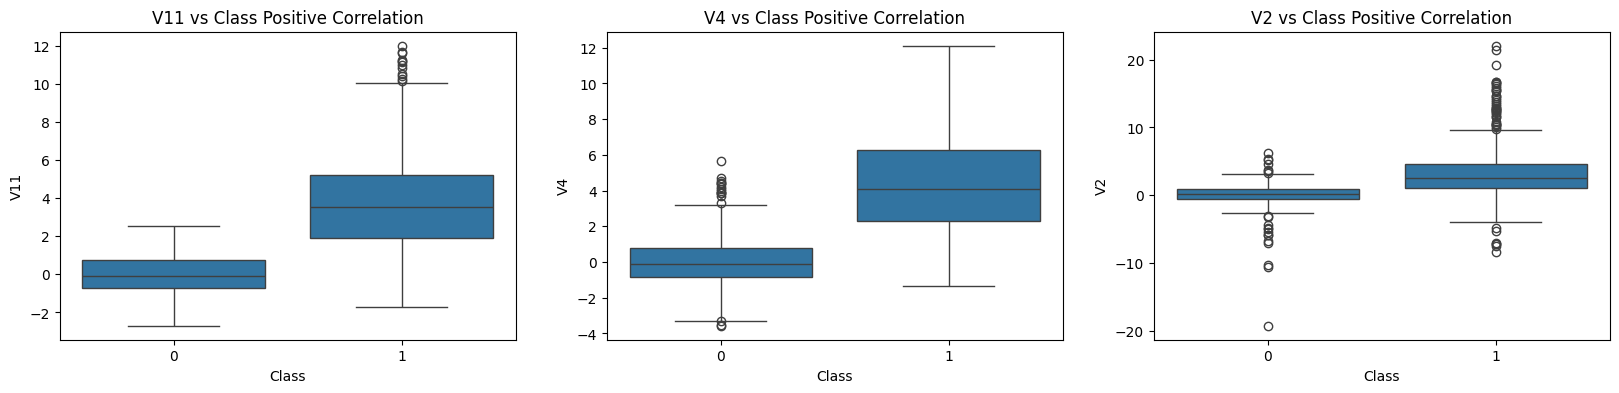

In [58]:
f, axes = plt.subplots(ncols=3, figsize=(20,4))

# Positive correlations (The higher the feature the probability increases that it will be a fraud transaction)
sns.boxplot(x="Class", y="V11", data=US, ax=axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V4", data=US, ax=axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V2", data=US, ax=axes[2])
axes[2].set_title('V2 vs Class Positive Correlation')

plt.show()

# Feature Engineering

In This Section, We will scale the other Features (Amount, Time), since the other Features are already transformed with PCA

In [ ]:
# Since most of our data has already been scaled we should scale the columns that are left to scale (Amount and Time)

# RobustScaler is less prone to outliers.

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = std_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [63]:
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
120117,-1.519717,0.433479,1.149406,-0.901235,-1.252229,0.383694,-0.814303,-0.877123,1.071440,-1.335820,...,0.561976,-0.146085,0.243662,-0.124452,-0.462560,0.325230,-0.061729,0,0.931720,-0.402163
88596,-0.827222,1.136662,1.064325,-0.161379,-0.166702,-0.462355,0.214212,0.545229,-0.761496,-0.362703,...,-0.581422,0.000062,-0.029704,-0.161674,0.076832,0.132587,0.034959,0,-0.153108,-0.686656
11302,-0.283964,0.964911,-0.162600,-0.910459,2.612856,3.319335,0.031369,0.853589,0.780271,-0.818031,...,-1.192433,-0.035384,0.874372,-0.029178,0.049413,0.220044,0.084754,0,-0.250452,-1.582846
218884,1.982381,0.785579,-1.254822,3.715296,1.050999,-0.099115,0.642429,-0.253253,-1.295728,1.438781,...,0.053620,0.119620,0.737476,0.281375,-0.015479,-0.059699,-0.052539,0,-0.305938,0.983487
263583,0.137239,0.900940,-0.420057,-0.511404,0.736477,-0.915825,0.844733,-0.010279,0.224273,-0.779577,...,-0.975032,0.122540,0.580093,-0.488331,0.115435,0.210573,0.081061,0,-0.274232,1.394473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6421,-0.614323,0.279876,1.332420,0.438336,0.829022,-0.597133,0.194265,0.030112,0.851630,-0.624904,...,0.169465,0.269339,-0.085687,-1.056114,-0.863693,0.191951,0.242042,0,0.194688,-1.836632
142670,-0.988430,1.039774,1.893100,0.247034,0.038396,1.057292,-0.239187,0.780583,-0.385681,-0.857871,...,0.069897,-0.443029,-1.002461,0.541087,-0.310404,-0.009945,-0.001271,0,-0.237658,-0.209370
110997,1.123233,-0.922807,0.051259,-0.448001,-1.199632,-1.114103,-0.167249,-0.290104,-0.851742,0.650409,...,-0.757920,-0.075431,0.404468,0.198953,1.027306,-0.097456,0.028581,0,1.831317,-0.479288
93323,-0.812406,0.852145,2.210813,0.353122,-0.832592,0.333340,-0.545221,0.795029,-0.634765,-0.533928,...,0.605147,-0.120593,0.262035,-0.006951,0.488519,-0.110550,-0.083128,0,-0.195105,-0.641459


In [68]:
df.to_csv("../data/preprocessed/creditcard_Processed.csv", index=False)